# Random Forest Models with Feature Engineering for Rocket Launch Failure Risk

This notebook follows the same modeling process as the baseline random forest notebook, but
adds a dedicated feature-engineering stage before fitting any models.

The modeling sequence stays the same:

1. fit a **base launch-only random forest**
2. fit a **base launch + weather random forest**
3. tune a **launch-only random forest**
4. tune a **launch + weather random forest**
5. compare the models on validation, then evaluate the final versions on the holdout test split

The target is still `is_failure_or_partial`, where `1` means a failed or partially failed
launch and `0` means a successful launch. The `data_split` column still controls the train,
validation, and test partitions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

ROOT = Path.cwd()
if not (ROOT / "launch_modeling_base_with_weather.csv").exists() and (
    ROOT.parent / "launch_modeling_base_with_weather.csv"
).exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "launch_modeling_base_with_weather.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
TARGET_COL = "is_failure_or_partial"

## Load the Modeling Table

This notebook starts from the same cleaned launch-level table used in the baseline
notebook. That keeps the comparison focused on feature engineering rather than on changes to
the underlying data source.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nSplit counts:")
print(df["data_split"].value_counts().sort_index())
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(normalize=True).rename("share").round(4))

df.head()

Dataset shape: 6,168 rows x 88 columns

Split counts:
data_split
test           926
train         4317
validation     925
Name: count, dtype: int64

Target distribution:
is_failure_or_partial
0    0.9121
1    0.0879
Name: share, dtype: float64


,Launch Id,launch_time_utc,launch_date,launch_year,launch_month,launch_month_name,launch_quarter,launch_dayofweek,launch_hour_utc,launch_decade,Launch Status,is_success,is_failure_or_partial,Launch Suborbital,is_suborbital,Rocket Name,Rocket Organisation,company_country,company_ownership,Rocket Price,Rocket Price CPI Adjusted,Rocket Payload to LEO,USD/kg to LEO,USD/kg to LEO CPI Adjusted,Location,Country,Country_Code,Operator,Launch Site,Comb Launch Site,facility_group,Lat,Lon,Launch Site Lat,Launch Site Lon,Comb Launch Site Lat,Comb Launch Site Lon,facility_lat,facility_lon,facility_coordinate_source,payload_count,mission_mass,mission_rows,config_status,config_price_musd_text_parsed,config_liftoff_thrust,config_payload_leo,config_payload_gto,config_stages,config_strap_ons,config_rocket_height,config_fairing_diameter,config_fairing_height,rocket_family,family_success_rate_pct,location_joined,mission_joined,config_joined,company_joined,launch_time_lstd,weather_obs_time_lstd,weather_matched,weather_time_diff_minutes,weather_file_name,weather_station_id,DATE,REPORT_TYPE,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlySeaLevelPressure,HourlyWindSpeed,HourlyWindDirection,hourly_nonnulls,present_weather_rain_flag,present_weather_fog_flag,present_weather_thunder_flag,cloud_cover_broken_or_overcast_flag,short_duration_precip_max,HourlyStationPressure,HourlyRelativeHumidity,HourlyAltimeterSetting,HourlyPrecipitation,HourlyVisibility,HourlyWindGustSpeed,HourlyWetBulbTemperature,HourlyPresentWeatherType,HourlySkyConditions,data_split
0,590,1957-10-04 19:28:00+00:00,1957-10-04,1957,10,October,4,4,19,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,84.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-10-05 00:28:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
1,593,1957-11-03 02:30:00+00:00,1957-11-03,1957,11,November,4,6,2,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,508.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-11-03 07:30:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
2,845,1957-12-06 16:44:00+00:00,1957-12-06,1957,12,December,4,4,16,1950,Failure,0,1,Orbital,0,Vanguard,US Navy,USA,State,NaN,NaN,10.0,NaN,NaN,"LC-18A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.448986,-80.561827,28.489690,-80.563003,28.501081,-80.567792,28.448986,-80.561827,Locations.csv raw Lat/Lon,1.0,2.0,1.0,Retired,NaN,135.0,10.0,NaN,3.0,0.0,23.0,NaN,NaN,Vanguard,22.7,True,True,True,True,1957-12-06 11:44:00,1957-12-06 12:00:00,True,16.0,cape_canaveral_sfs.csv,USW00012868,1957-12-06T12:00:00,SAO,70.0,53.0,30.37,16.0,110.0,11.0,False,False,False,False,NaN,30.35,55.0,NaN,NaN,9.94,NaN,60.0,||00,SCT:03 44,train
3,844,1958-02-01 03:47:00+00:00,1958-02-01,1958,2,February,1,5,3,1950,Success,1,0,Orbital,0,Juno I,ABMA,USA,State,NaN,NaN,11.0,NaN,NaN,"LC-26A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.439421,-80.573307,28.489690,-80.563003,28.501081

## Define the Starting Feature Sets

As in the baseline notebook, the model inputs use explicit include lists so it is easy to
audit exactly which source columns are allowed into the pipeline.

These are the **original source features**. Later sections will add engineered columns on
top of them while preserving the same two-pattern structure:

- launch-only
- launch + weather

In [3]:
launch_only_features = [
    "launch_year",
    "launch_month",
    "launch_month_name",
    "launch_quarter",
    "launch_dayofweek",
    "launch_hour_utc",
    "launch_decade",
    "Launch Suborbital",
    "is_suborbital",
    "Rocket Name",
    "Rocket Organisation",
    "company_country",
    "company_ownership",
    "Rocket Price",
    "Rocket Price CPI Adjusted",
    "Rocket Payload to LEO",
    "USD/kg to LEO",
    "USD/kg to LEO CPI Adjusted",
    "Location",
    "Country",
    "Country_Code",
    "Operator",
    "Launch Site",
    "Comb Launch Site",
    "facility_group",
    "Lat",
    "Lon",
    "Launch Site Lat",
    "Launch Site Lon",
    "Comb Launch Site Lat",
    "Comb Launch Site Lon",
    "facility_lat",
    "facility_lon",
    "payload_count",
    "mission_mass",
    "mission_rows",
    "config_price_musd_text_parsed",
    "config_liftoff_thrust",
    "config_payload_leo",
    "config_payload_gto",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "config_fairing_diameter",
    "config_fairing_height",
    "rocket_family",
]

weather_feature_cols = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "short_duration_precip_max",
    "HourlyStationPressure",
    "HourlyRelativeHumidity",
    "HourlyAltimeterSetting",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindGustSpeed",
    "HourlyWetBulbTemperature",
    "HourlyPresentWeatherType",
    "HourlySkyConditions",
]

missing_launch_features = [col for col in launch_only_features if col not in df.columns]
missing_weather_features = [col for col in weather_feature_cols if col not in df.columns]

if missing_launch_features or missing_weather_features:
    raise ValueError(
        "One or more expected modeling columns are missing. "
        f"Launch-only missing: {missing_launch_features}. "
        f"Weather missing: {missing_weather_features}."
    )

original_weather_features = launch_only_features + weather_feature_cols

pd.DataFrame(
    {
        "feature_set": ["original_launch_only", "original_launch_plus_weather"],
        "num_features": [len(launch_only_features), len(original_weather_features)],
    }
)

,feature_set,num_features
0,original_launch_only,46
1,original_launch_plus_weather,65


## Why Engineer Features?

Random forests can capture nonlinear structure, but they still benefit from predictor
columns that make the underlying launch physics and operating conditions easier to learn.
The engineered features in this notebook are intentionally **row-wise** and **split-safe**:

- they use only information from the same launch record
- they do not aggregate outcomes across rows
- they do not use the validation or test splits to define target-related statistics

That makes them appropriate for a predictive workflow that respects the provided splits.

## Feature Engineering Plan

The engineered features are grouped into two buckets:

- **launch-derived features**
  - cyclical encodings for month, weekday, and hour
  - log transforms for heavily skewed scale variables
  - ratios that normalize mission mass, price, and thrust
  - geometry and location-gap features that summarize rocket size and facility alignment
- **weather-derived features**
  - temperature and moisture spreads
  - wind-vector components and gust relationships
  - compact operational flags for precipitation, low visibility, and storm risk

Keeping those groups separate lets us preserve the same launch-only versus launch+weather
comparison structure used in the baseline notebook.

In [4]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    engineered = df.copy()

    # Cyclical launch timing features preserve seasonality and daily timing without
    # forcing the model to treat month 12 and month 1 as far apart.
    engineered["launch_month_sin"] = np.sin(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_month_cos"] = np.cos(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_dayofweek_sin"] = np.sin(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_dayofweek_cos"] = np.cos(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_hour_sin"] = np.sin(2 * np.pi * engineered["launch_hour_utc"] / 24)
    engineered["launch_hour_cos"] = np.cos(2 * np.pi * engineered["launch_hour_utc"] / 24)

    # Log features reduce the influence of extreme scale values while keeping ordering.
    engineered["rocket_price_log"] = np.log1p(engineered["Rocket Price CPI Adjusted"].clip(lower=0))
    engineered["rocket_payload_log"] = np.log1p(engineered["Rocket Payload to LEO"].clip(lower=0))
    engineered["mission_mass_log"] = np.log1p(engineered["mission_mass"].clip(lower=0))

    # Ratios connect cost, mission size, and configuration capacity on the same scale.
    engineered["payloads_per_mission_row"] = safe_divide(engineered["payload_count"], engineered["mission_rows"])
    engineered["mission_mass_per_payload"] = safe_divide(engineered["mission_mass"], engineered["payload_count"])
    engineered["price_per_payload_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["Rocket Payload to LEO"],
    )
    engineered["price_per_mission_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["mission_mass"],
    )
    engineered["thrust_to_leo_payload_ratio"] = safe_divide(
        engineered["config_liftoff_thrust"],
        engineered["config_payload_leo"],
    )
    engineered["gto_to_leo_capacity_ratio"] = safe_divide(
        engineered["config_payload_gto"],
        engineered["config_payload_leo"],
    )
    engineered["mission_to_leo_capacity_ratio"] = safe_divide(
        engineered["mission_mass"],
        engineered["config_payload_leo"],
    )

    # Geometry and location features summarize vehicle proportions and site consistency.
    engineered["rocket_height_to_fairing_height_ratio"] = safe_divide(
        engineered["config_rocket_height"],
        engineered["config_fairing_height"],
    )
    engineered["fairing_volume_proxy"] = (
        engineered["config_fairing_diameter"] ** 2
    ) * engineered["config_fairing_height"]
    engineered["total_stage_elements"] = (
        engineered["config_stages"].fillna(0) + engineered["config_strap_ons"].fillna(0)
    )
    engineered["launch_latitude_gap"] = (engineered["Lat"] - engineered["facility_lat"]).abs()
    engineered["launch_longitude_gap"] = (engineered["Lon"] - engineered["facility_lon"]).abs()
    engineered["site_to_facility_lat_gap"] = (
        engineered["Launch Site Lat"] - engineered["facility_lat"]
    ).abs()
    engineered["site_to_facility_lon_gap"] = (
        engineered["Launch Site Lon"] - engineered["facility_lon"]
    ).abs()

    # Weather-derived physics and operational flags.
    engineered["temperature_dewpoint_spread"] = (
        engineered["HourlyDryBulbTemperature"] - engineered["HourlyDewPointTemperature"]
    )
    engineered["pressure_gap"] = (
        engineered["HourlySeaLevelPressure"] - engineered["HourlyStationPressure"]
    )
    engineered["gust_minus_wind_speed"] = (
        engineered["HourlyWindGustSpeed"] - engineered["HourlyWindSpeed"]
    )
    engineered["wetbulb_depression"] = (
        engineered["HourlyDryBulbTemperature"] - engineered["HourlyWetBulbTemperature"]
    )

    wind_direction_radians = np.deg2rad(engineered["HourlyWindDirection"])
    engineered["wind_u_component"] = engineered["HourlyWindSpeed"] * np.cos(wind_direction_radians)
    engineered["wind_v_component"] = engineered["HourlyWindSpeed"] * np.sin(wind_direction_radians)
    engineered["wind_gust_ratio"] = safe_divide(
        engineered["HourlyWindGustSpeed"],
        engineered["HourlyWindSpeed"],
    )

    engineered["precipitation_any_flag"] = (
        (engineered["HourlyPrecipitation"].fillna(0) > 0)
        | (engineered["short_duration_precip_max"].fillna(0) > 0)
        | (engineered["present_weather_rain_flag"].astype(str) == "True")
    ).astype(int)
    engineered["low_visibility_flag"] = (engineered["HourlyVisibility"].fillna(99) < 5).astype(int)
    engineered["high_humidity_flag"] = (engineered["HourlyRelativeHumidity"].fillna(-1) >= 85).astype(int)
    engineered["storm_risk_flag"] = (
        (engineered["present_weather_thunder_flag"].astype(str) == "True")
        | (
            (engineered["HourlyWindGustSpeed"].fillna(0) >= 25)
            & (engineered["HourlyPrecipitation"].fillna(0) > 0)
        )
    ).astype(int)

    return engineered


df_engineered = engineer_features(df)

In [5]:
engineered_launch_features = [
    "launch_month_sin",
    "launch_month_cos",
    "launch_dayofweek_sin",
    "launch_dayofweek_cos",
    "launch_hour_sin",
    "launch_hour_cos",
    "rocket_price_log",
    "rocket_payload_log",
    "mission_mass_log",
    "payloads_per_mission_row",
    "mission_mass_per_payload",
    "price_per_payload_kg",
    "price_per_mission_kg",
    "thrust_to_leo_payload_ratio",
    "gto_to_leo_capacity_ratio",
    "mission_to_leo_capacity_ratio",
    "rocket_height_to_fairing_height_ratio",
    "fairing_volume_proxy",
    "total_stage_elements",
    "launch_latitude_gap",
    "launch_longitude_gap",
    "site_to_facility_lat_gap",
    "site_to_facility_lon_gap",
]

engineered_weather_features = [
    "temperature_dewpoint_spread",
    "pressure_gap",
    "gust_minus_wind_speed",
    "wetbulb_depression",
    "wind_u_component",
    "wind_v_component",
    "wind_gust_ratio",
    "precipitation_any_flag",
    "low_visibility_flag",
    "high_humidity_flag",
    "storm_risk_flag",
]

missing_engineered_launch = [col for col in engineered_launch_features if col not in df_engineered.columns]
missing_engineered_weather = [col for col in engineered_weather_features if col not in df_engineered.columns]

if missing_engineered_launch or missing_engineered_weather:
    raise ValueError(
        "One or more engineered columns were not created correctly. "
        f"Launch engineered missing: {missing_engineered_launch}. "
        f"Weather engineered missing: {missing_engineered_weather}."
    )

launch_model_features = launch_only_features + engineered_launch_features
weather_model_features = launch_model_features + weather_feature_cols + engineered_weather_features

pd.DataFrame(
    {
        "feature_set": [
            "engineered_launch_only",
            "engineered_launch_plus_weather",
        ],
        "num_features": [
            len(launch_model_features),
            len(weather_model_features),
        ],
    }
)

,feature_set,num_features
0,engineered_launch_only,69
1,engineered_launch_plus_weather,99


## Review the Engineered Features

Before training models, it is useful to confirm that the new columns look sensible and to
understand how much missingness they inherit from the source data.

In [6]:
engineered_feature_catalog = pd.DataFrame(
    {
        "feature_group": (
            ["launch_engineered"] * len(engineered_launch_features)
            + ["weather_engineered"] * len(engineered_weather_features)
        ),
        "feature_name": engineered_launch_features + engineered_weather_features,
    }
)
engineered_feature_catalog

,feature_group,feature_name
0,launch_engineered,launch_month_sin
1,launch_engineered,launch_month_cos
2,launch_engineered,launch_dayofweek_sin
3,launch_engineered,launch_dayofweek_cos
4,launch_engineered,launch_hour_sin
5,launch_engineered,launch_hour_cos
6,launch_engineered,rocket_price_log
7,launch_engineered,rocket_payload_log
8,launch_engineered,mission_mass_log
9,launch_engineered,payloads_per_mission_row


In [7]:
engineered_missingness = (
    df_engineered[engineered_launch_features + engineered_weather_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .rename("missing_pct")
)

engineered_missingness.head(15).to_frame()

,missing_pct
wind_gust_ratio,98.621920
gust_minus_wind_speed,98.605707
wetbulb_depression,83.187419
pressure_gap,81.955253
price_per_mission_kg,68.158236
price_per_payload_kg,63.683528
rocket_price_log,63.164721
wind_v_component,53.047990
wind_u_component,53.047990
temperature_dewpoint_spread,50.761997


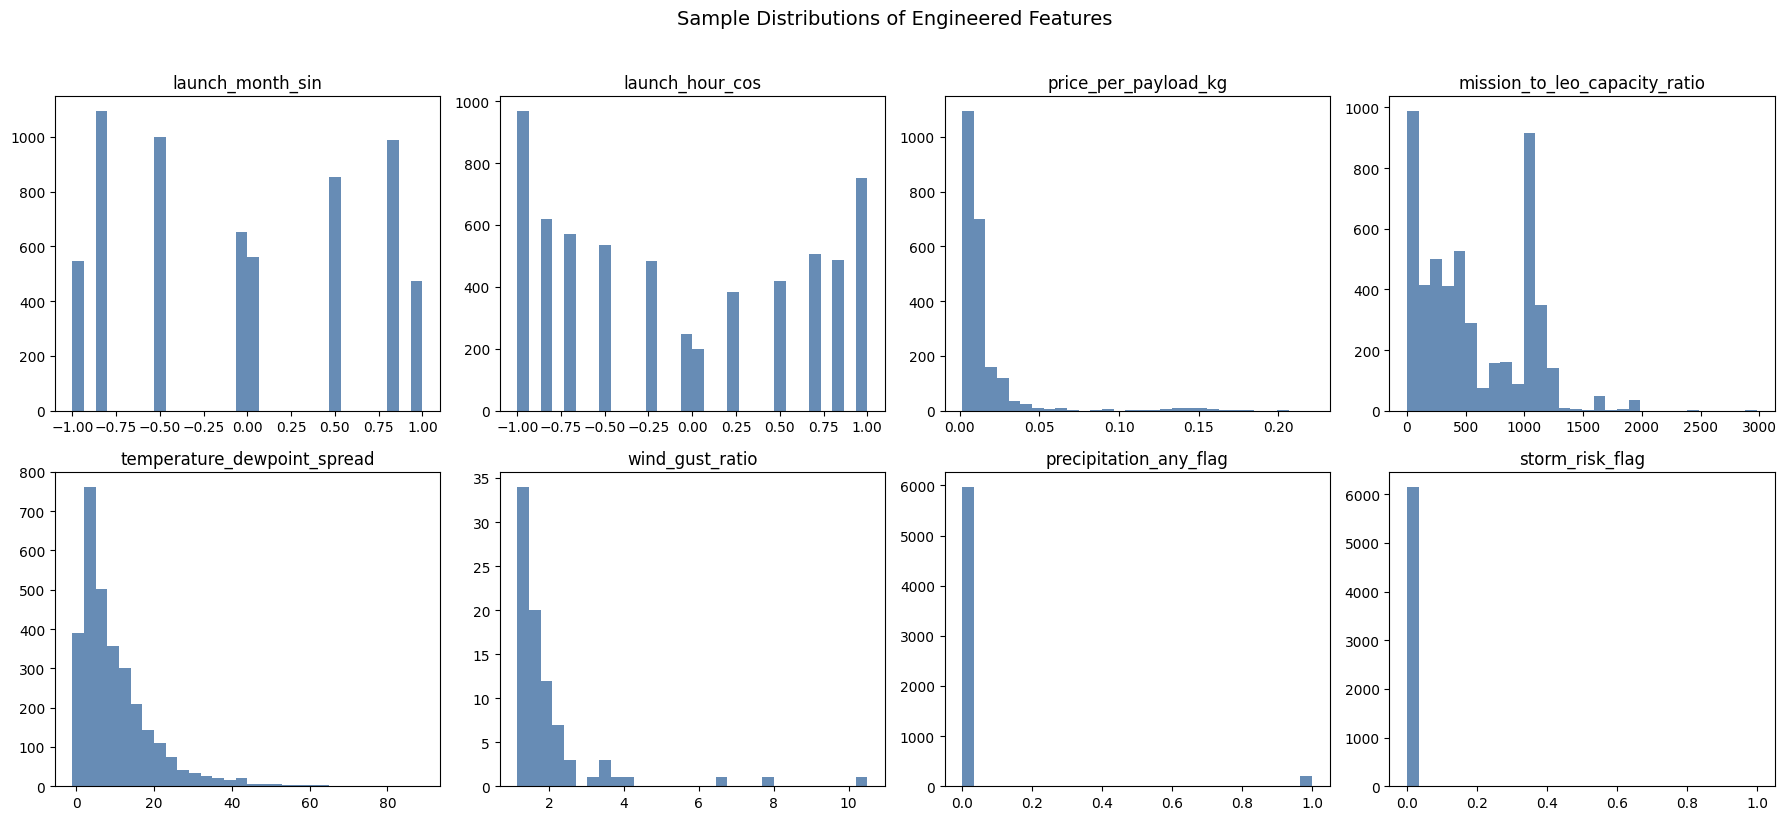

In [8]:
preview_cols = [
    "launch_month_sin",
    "launch_hour_cos",
    "price_per_payload_kg",
    "mission_to_leo_capacity_ratio",
    "temperature_dewpoint_spread",
    "wind_gust_ratio",
    "precipitation_any_flag",
    "storm_risk_flag",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, col in zip(axes, preview_cols):
    series = df_engineered[col].dropna()
    ax.hist(series, bins=30, color="#4c78a8", alpha=0.85)
    ax.set_title(col)

plt.suptitle("Sample Distributions of Engineered Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Inspect the Modeling Splits and Class Balance

The feature engineering changes the columns, but it does not change the split discipline or
the class imbalance problem. Those two facts still shape how the models should be judged.

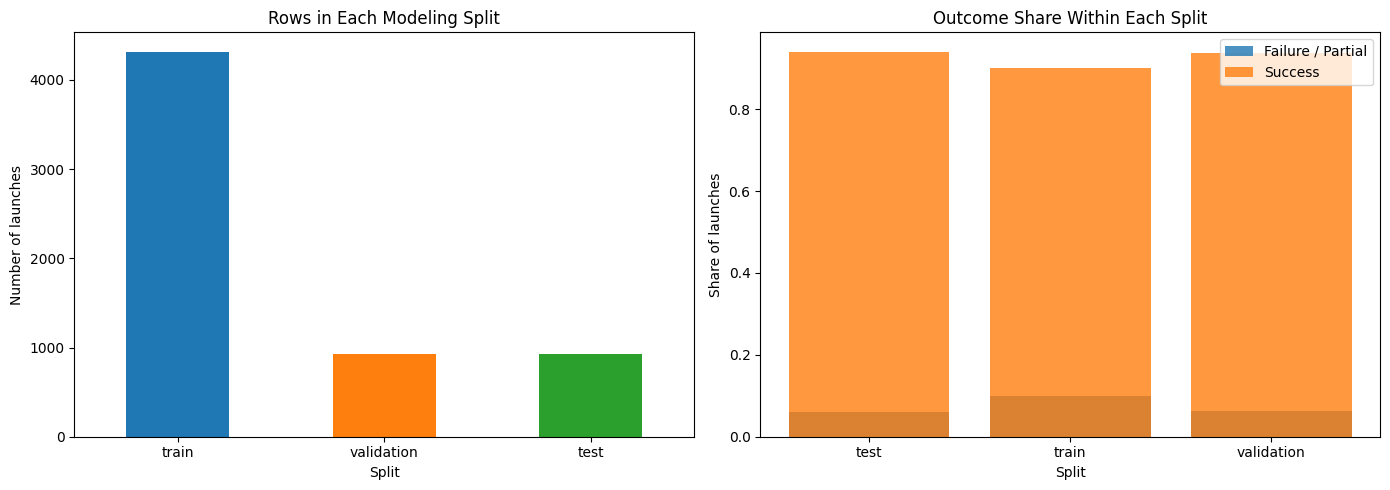

In [9]:
split_counts = (
    df_engineered["data_split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
)

target_by_split = (
    df_engineered.groupby("data_split")[TARGET_COL]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)
target_by_split["launch_outcome"] = target_by_split[TARGET_COL].map({1: "Failure / Partial", 0: "Success"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_counts.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title("Rows in Each Modeling Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Number of launches")
axes[0].tick_params(axis="x", rotation=0)

for outcome_name, group in target_by_split.groupby("launch_outcome"):
    axes[1].bar(group["data_split"], group["share"], label=outcome_name, alpha=0.8)
axes[1].set_title("Outcome Share Within Each Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Share of launches")
axes[1].legend()

plt.tight_layout()
plt.show()

## Create Split DataFrames

The split masks and train/validation/test matrices are created once here so the rest of the
notebook uses the same data partitions consistently.

In [10]:
train_mask = df_engineered["data_split"].eq("train")
val_mask = df_engineered["data_split"].eq("validation")
test_mask = df_engineered["data_split"].eq("test")
trainval_mask = df_engineered["data_split"].isin(["train", "validation"])

y_train = df_engineered.loc[train_mask, TARGET_COL]
y_val = df_engineered.loc[val_mask, TARGET_COL]
y_test = df_engineered.loc[test_mask, TARGET_COL]
y_trainval = df_engineered.loc[trainval_mask, TARGET_COL]

split_data = {
    "launch_only": {
        "X_train": df_engineered.loc[train_mask, launch_model_features],
        "X_val": df_engineered.loc[val_mask, launch_model_features],
        "X_test": df_engineered.loc[test_mask, launch_model_features],
        "X_trainval": df_engineered.loc[trainval_mask, launch_model_features],
    },
    "launch_plus_weather": {
        "X_train": df_engineered.loc[train_mask, weather_model_features],
        "X_val": df_engineered.loc[val_mask, weather_model_features],
        "X_test": df_engineered.loc[test_mask, weather_model_features],
        "X_trainval": df_engineered.loc[trainval_mask, weather_model_features],
    },
}

{
    name: {split_name: split_df.shape for split_name, split_df in parts.items()}
    for name, parts in split_data.items()
}

{'launch_only': {'X_train': (4317, 69),
  'X_val': (925, 69),
  'X_test': (926, 69),
  'X_trainval': (5242, 69)},
 'launch_plus_weather': {'X_train': (4317, 99),
  'X_val': (925, 99),
  'X_test': (926, 99),
  'X_trainval': (5242, 99)}}

## Modeling Helpers

The helper code below is the same general workflow as the baseline notebook:

- impute numeric and categorical missing values
- convert mixed categorical flags to strings before one-hot encoding
- fit random forests inside a scikit-learn pipeline
- evaluate with confusion matrices, ROC curves, and imbalance-aware metrics
- use a predefined train/validation split for hyperparameter tuning

In [11]:
def build_pipeline(X: pd.DataFrame, rf_params: dict | None = None) -> Pipeline:
    rf_params = rf_params or {}

    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                        (
                            "to_string",
                            FunctionTransformer(
                                lambda data: data.astype(str),
                                feature_names_out="one-to-one",
                            ),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

    model_defaults = {
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "class_weight": "balanced_subsample",
    }
    model_defaults.update(rf_params)

    model = RandomForestClassifier(**model_defaults)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def collect_metrics(model: Pipeline, X: pd.DataFrame, y_true: pd.Series, split_name: str, model_name: str):
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "failure_precision": precision_score(y_true, y_pred, zero_division=0),
        "failure_recall": recall_score(y_true, y_pred, zero_division=0),
        "success_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
    }


def metrics_frame(metric_rows: list[dict]) -> pd.DataFrame:
    metric_cols = [
        "accuracy",
        "balanced_accuracy",
        "failure_recall",
        "failure_precision",
        "success_recall",
        "f1",
        "roc_auc",
    ]
    out = pd.DataFrame(metric_rows)
    out[metric_cols] = out[metric_cols].round(4)
    return out


def run_random_search(X_train: pd.DataFrame, X_val: pd.DataFrame, y_train: pd.Series, y_val: pd.Series):
    X_dev = pd.concat([X_train, X_val], axis=0)
    y_dev = pd.concat([y_train, y_val], axis=0)
    split_index = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
    predefined_split = PredefinedSplit(test_fold=split_index)

    param_distributions = {
        "model__n_estimators": [200, 400, 600, 800],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.4, 0.6, None],
        "model__max_leaf_nodes": [None, 32, 64, 128, 256],
    }

    search = RandomizedSearchCV(
        estimator=build_pipeline(X_train),
        param_distributions=param_distributions,
        n_iter=20,
        scoring="roc_auc",
        cv=predefined_split,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=False,
        verbose=0,
    )
    search.fit(X_dev, y_dev)

    best_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}

    search_results = (
        pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        .loc[
            :,
            [
                "rank_test_score",
                "mean_test_score",
                "param_model__n_estimators",
                "param_model__max_depth",
                "param_model__min_samples_split",
                "param_model__min_samples_leaf",
                "param_model__max_features",
                "param_model__max_leaf_nodes",
            ],
        ]
        .rename(columns={"mean_test_score": "validation_roc_auc"})
    )
    search_results["validation_roc_auc"] = search_results["validation_roc_auc"].round(4)

    return best_params, search_results


def fit_model(X_train: pd.DataFrame, y_train: pd.Series, rf_params: dict | None = None):
    model = build_pipeline(X_train, rf_params=rf_params)
    model.fit(X_train, y_train)
    return model


def get_feature_importance_frame(model: Pipeline, top_n: int = 15) -> pd.DataFrame:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    importances = model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)
    return importance_df.head(top_n)


def interpretation_text(metrics_df: pd.DataFrame, focus_split: str) -> str:
    subset = metrics_df.loc[metrics_df["split"] == focus_split].copy()
    top_auc = subset.sort_values("roc_auc", ascending=False).iloc[0]
    top_balanced = subset.sort_values("balanced_accuracy", ascending=False).iloc[0]

    lines = [
        f"Best ROC AUC on {focus_split}: {top_auc['model']} ({top_auc['roc_auc']:.4f}).",
        f"Best balanced accuracy on {focus_split}: {top_balanced['model']} ({top_balanced['balanced_accuracy']:.4f}).",
    ]

    if {"Base Launch-Only", "Base Launch + Weather"}.issubset(set(subset["model"])):
        launch_base_auc = subset.loc[subset["model"] == "Base Launch-Only", "roc_auc"].iloc[0]
        weather_base_auc = subset.loc[subset["model"] == "Base Launch + Weather", "roc_auc"].iloc[0]
        lines.append(f"Weather lift in the base models: {weather_base_auc - launch_base_auc:+.4f} ROC AUC.")

    if {"Tuned Launch-Only", "Tuned Launch + Weather"}.issubset(set(subset["model"])):
        launch_tuned_auc = subset.loc[subset["model"] == "Tuned Launch-Only", "roc_auc"].iloc[0]
        weather_tuned_auc = subset.loc[subset["model"] == "Tuned Launch + Weather", "roc_auc"].iloc[0]
        lines.append(f"Weather lift in the tuned models: {weather_tuned_auc - launch_tuned_auc:+.4f} ROC AUC.")

    return "\n".join(lines)

## Fit the Two Base Models

The first pair of models uses the engineered feature sets but keeps the random forest
hyperparameters at their default values. This gives a clean baseline for asking whether the
engineered features help even before tuning.

In [12]:
base_models = {
    "Base Launch-Only": fit_model(
        split_data["launch_only"]["X_train"],
        y_train,
    ),
    "Base Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_train"],
        y_train,
    ),
}

base_models.keys()

dict_keys(['Base Launch-Only', 'Base Launch + Weather'])

## Evaluate the Base Models on the Validation Split

This is the first development-stage comparison. It shows whether the engineered predictors
help the untuned launch-only model and whether the weather-enhanced version adds anything on
top of that.

In [13]:
base_validation_metrics = metrics_frame(
    [
        collect_metrics(
            base_models["Base Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            base_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch + Weather",
        ),
    ]
)

base_validation_metrics

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
0,Base Launch-Only,validation,0.9373,0.5076,0.3333,0.0175,0.9977,0.0333,0.6699,866,2,56,1
1,Base Launch + Weather,validation,0.9362,0.4988,0.0000,0.0000,0.9977,0.0000,0.6615,866,2,57,0


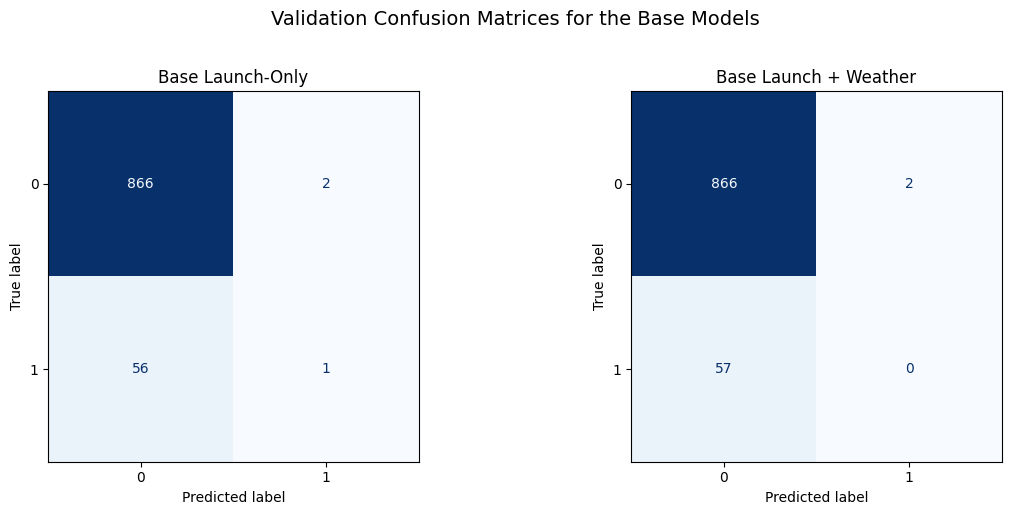

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_name, X_val_current) in zip(
    axes,
    [
        ("Base Launch-Only", split_data["launch_only"]["X_val"]),
        ("Base Launch + Weather", split_data["launch_plus_weather"]["X_val"]),
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        base_models[model_name].predict(X_val_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Validation Confusion Matrices for the Base Models", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

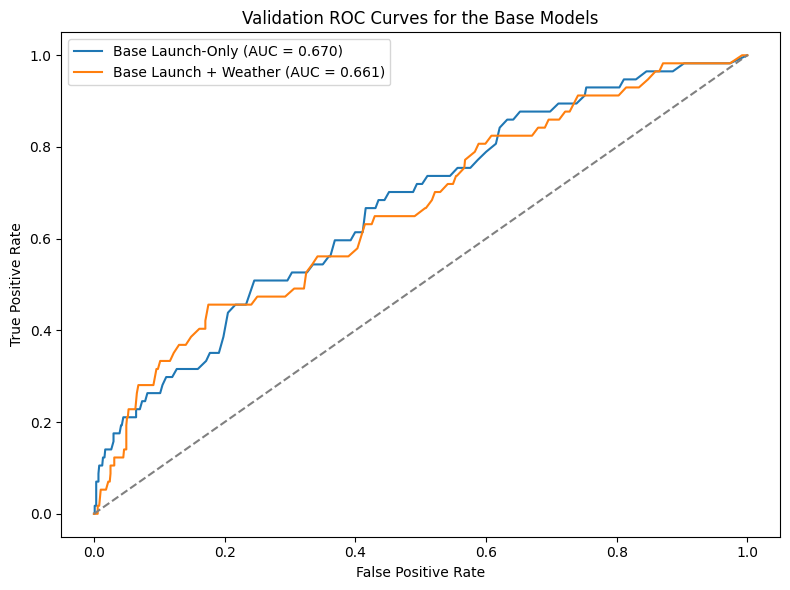

In [15]:
plt.figure(figsize=(8, 6))
for model_name, X_val_current in [
    ("Base Launch-Only", split_data["launch_only"]["X_val"]),
    ("Base Launch + Weather", split_data["launch_plus_weather"]["X_val"]),
]:
    y_score = base_models[model_name].predict_proba(X_val_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves for the Base Models")
plt.legend()
plt.tight_layout()
plt.show()

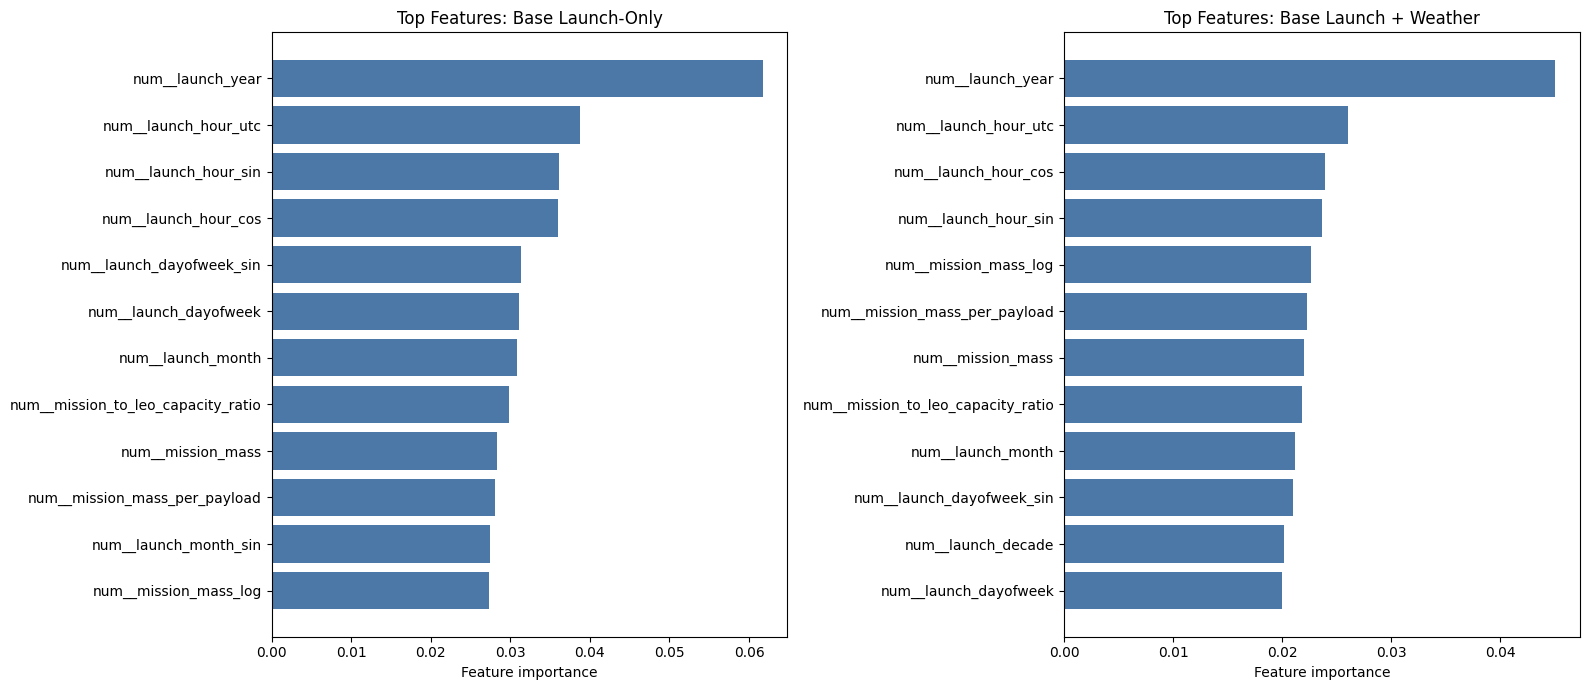

In [16]:
base_feature_importances = {
    model_name: get_feature_importance_frame(model, top_n=12)
    for model_name, model in base_models.items()
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (model_name, importance_df) in zip(axes, base_feature_importances.items()):
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color="#4c78a8",
    )
    ax.set_title(f"Top Features: {model_name}")
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.show()

In [17]:
print(interpretation_text(base_validation_metrics, focus_split="validation"))

Best ROC AUC on validation: Base Launch-Only (0.6699).
Best balanced accuracy on validation: Base Launch-Only (0.5076).
Weather lift in the base models: -0.0084 ROC AUC.


## Hyperparameter Tuning

The next step keeps the engineered feature sets fixed and tunes the forest hyperparameters.
The search still uses a `PredefinedSplit`, so every candidate model is trained on `train`
rows and judged on `validation` rows only.

In [18]:
launch_tuned_params, launch_search_results = run_random_search(
    split_data["launch_only"]["X_train"],
    split_data["launch_only"]["X_val"],
    y_train,
    y_val,
)

weather_tuned_params, weather_search_results = run_random_search(
    split_data["launch_plus_weather"]["X_train"],
    split_data["launch_plus_weather"]["X_val"],
    y_train,
    y_val,
)

pd.DataFrame(
    [
        {"model": "Tuned Launch-Only", **launch_tuned_params},
        {"model": "Tuned Launch + Weather", **weather_tuned_params},
    ]
)

,model,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth
0,Tuned Launch-Only,600,2,1,64,sqrt,None
1,Tuned Launch + Weather,600,2,1,64,sqrt,None


In [19]:
print("Top launch-only tuning candidates:")
display(launch_search_results.head(5))

print("Top weather-augmented tuning candidates:")
display(weather_search_results.head(5))

Top launch-only tuning candidates:


,rank_test_score,validation_roc_auc,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes
19,1,0.7071,600,None,2,1,sqrt,64
15,2,0.6990,200,12,5,8,sqrt,128
5,3,0.6886,800,16,5,1,log2,32
11,4,0.6845,600,16,5,2,log2,128
10,5,0.6829,600,None,2,2,log2,64


Top weather-augmented tuning candidates:


,rank_test_score,validation_roc_auc,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes
19,1,0.7006,600,None,2,1,sqrt,64
15,2,0.6995,200,12,5,8,sqrt,128
11,3,0.6860,600,16,5,2,log2,128
10,4,0.6808,600,None,2,2,log2,64
4,5,0.6742,600,16,10,4,log2,32


## Fit the Tuned Development Models

Once the best hyperparameters have been selected, the tuned models are fitted on the train
split so they can be compared directly against the base models on the validation split.

In [20]:
tuned_dev_models = {
    "Tuned Launch-Only": fit_model(
        split_data["launch_only"]["X_train"],
        y_train,
        rf_params=launch_tuned_params,
    ),
    "Tuned Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_train"],
        y_train,
        rf_params=weather_tuned_params,
    ),
}

tuned_dev_models.keys()

dict_keys(['Tuned Launch-Only', 'Tuned Launch + Weather'])

## Compare All Four Development Models on the Validation Split

This side-by-side comparison is the main development result for the notebook. It shows
whether the engineered features improve failure-risk prediction, whether weather adds
incremental value, and how much tuning changes the model behavior.

In [21]:
all_validation_metrics = metrics_frame(
    [
        collect_metrics(
            base_models["Base Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            base_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Base Launch + Weather",
        ),
        collect_metrics(
            tuned_dev_models["Tuned Launch-Only"],
            split_data["launch_only"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Tuned Launch-Only",
        ),
        collect_metrics(
            tuned_dev_models["Tuned Launch + Weather"],
            split_data["launch_plus_weather"]["X_val"],
            y_val,
            split_name="validation",
            model_name="Tuned Launch + Weather",
        ),
    ]
)

all_validation_metrics.sort_values(["roc_auc", "balanced_accuracy"], ascending=False)

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
2,Tuned Launch-Only,validation,0.8368,0.6098,0.1493,0.3509,0.8687,0.2094,0.7071,754,114,37,20
3,Tuned Launch + Weather,validation,0.8389,0.6273,0.1618,0.3860,0.8687,0.2280,0.7006,754,114,35,22
0,Base Launch-Only,validation,0.9373,0.5076,0.3333,0.0175,0.9977,0.0333,0.6699,866,2,56,1
1,Base Launch + Weather,validation,0.9362,0.4988,0.0000,0.0000,0.9977,0.0000,0.6615,866,2,57,0


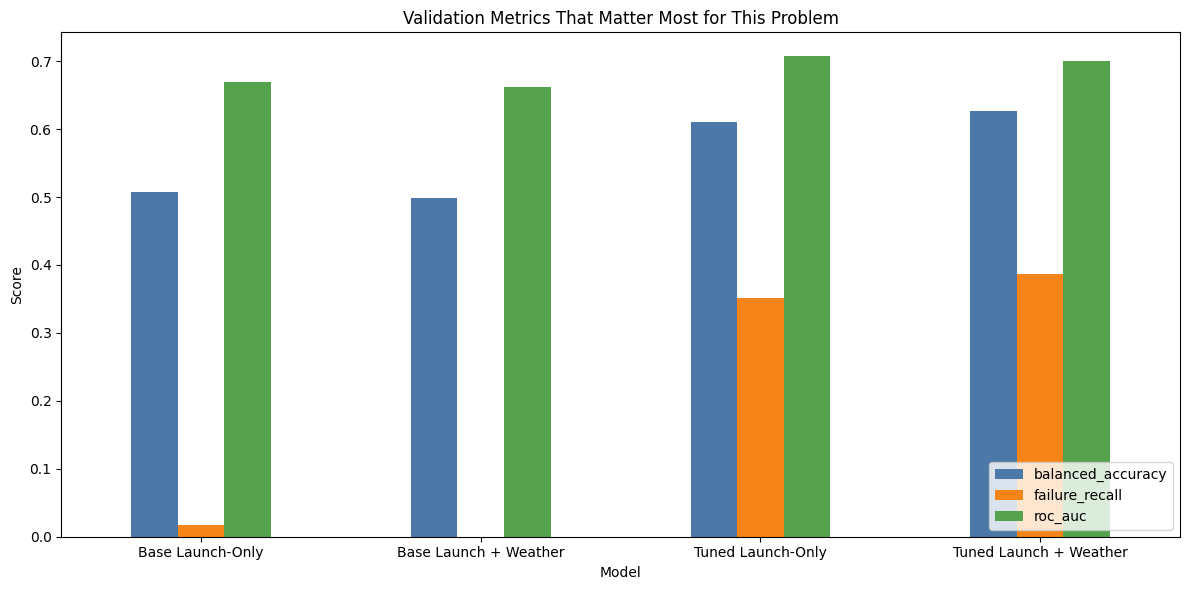

In [22]:
metric_plot_df = all_validation_metrics.set_index("model")[
    ["balanced_accuracy", "failure_recall", "roc_auc"]
]

metric_plot_df.plot(kind="bar", figsize=(12, 6), color=["#4c78a8", "#f58518", "#54a24b"])
plt.title("Validation Metrics That Matter Most for This Problem")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

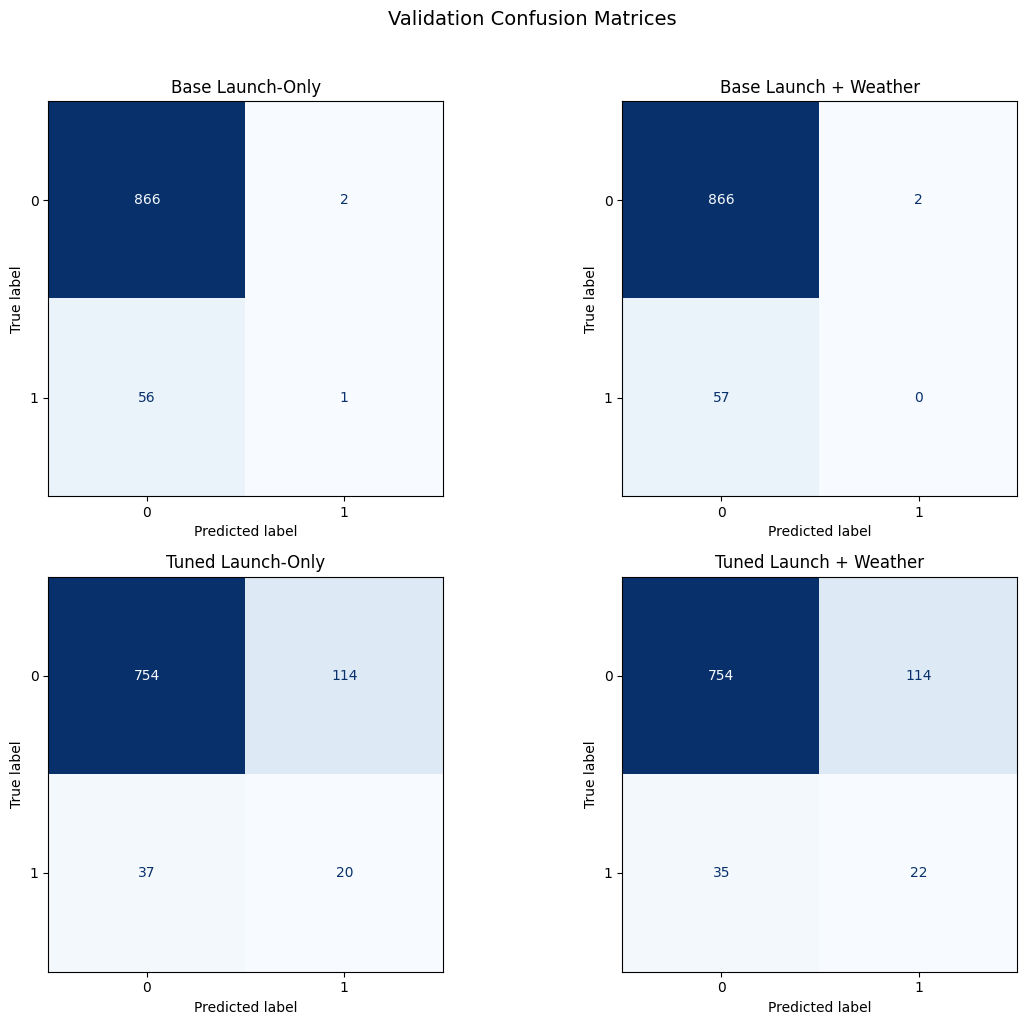

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

validation_plot_inputs = [
    ("Base Launch-Only", base_models["Base Launch-Only"], split_data["launch_only"]["X_val"]),
    ("Base Launch + Weather", base_models["Base Launch + Weather"], split_data["launch_plus_weather"]["X_val"]),
    ("Tuned Launch-Only", tuned_dev_models["Tuned Launch-Only"], split_data["launch_only"]["X_val"]),
    ("Tuned Launch + Weather", tuned_dev_models["Tuned Launch + Weather"], split_data["launch_plus_weather"]["X_val"]),
]

for ax, (model_name, model, X_val_current) in zip(axes, validation_plot_inputs):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        model.predict(X_val_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Validation Confusion Matrices", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

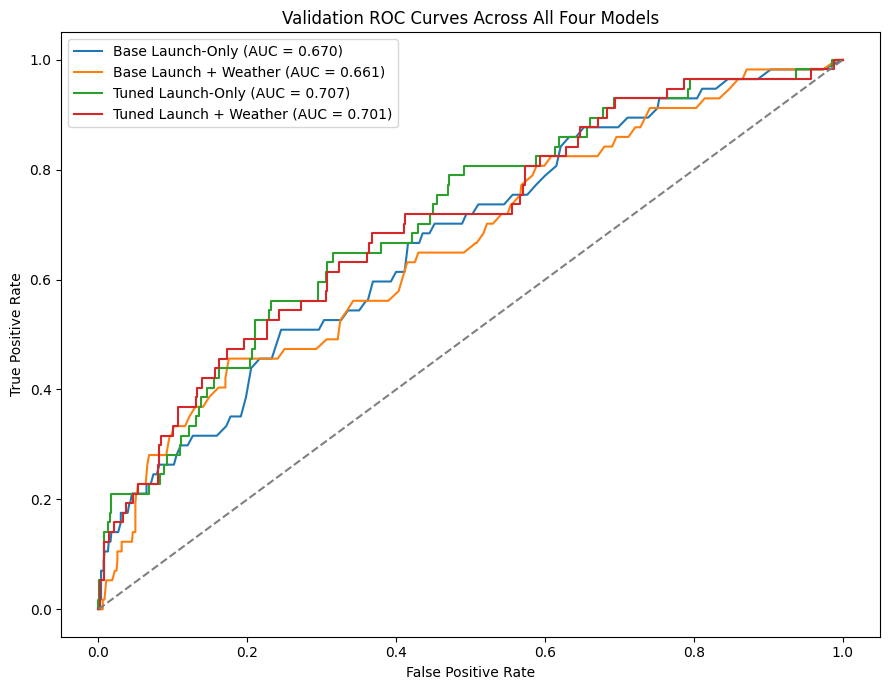

In [24]:
plt.figure(figsize=(9, 7))
for model_name, model, X_val_current in validation_plot_inputs:
    y_score = model.predict_proba(X_val_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves Across All Four Models")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
print(interpretation_text(all_validation_metrics, focus_split="validation"))

Best ROC AUC on validation: Tuned Launch-Only (0.7071).
Best balanced accuracy on validation: Tuned Launch + Weather (0.6273).
Weather lift in the base models: -0.0084 ROC AUC.
Weather lift in the tuned models: -0.0065 ROC AUC.


## Refit the Selected Model Configurations on Train + Validation

After the development comparison is complete, the final versions of each model are fitted on
the combined `train + validation` rows so they can be evaluated once on the untouched test
split.

In [26]:
final_models = {
    "Base Launch-Only": fit_model(
        split_data["launch_only"]["X_trainval"],
        y_trainval,
    ),
    "Base Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_trainval"],
        y_trainval,
    ),
    "Tuned Launch-Only": fit_model(
        split_data["launch_only"]["X_trainval"],
        y_trainval,
        rf_params=launch_tuned_params,
    ),
    "Tuned Launch + Weather": fit_model(
        split_data["launch_plus_weather"]["X_trainval"],
        y_trainval,
        rf_params=weather_tuned_params,
    ),
}

final_models.keys()

dict_keys(['Base Launch-Only', 'Base Launch + Weather', 'Tuned Launch-Only', 'Tuned Launch + Weather'])

## Final Holdout Test Evaluation

These results are the cleanest comparison in the notebook because the test split has not
been used during feature engineering design, hyperparameter tuning, or model selection.

In [27]:
final_test_metrics = metrics_frame(
    [
        collect_metrics(
            final_models["Base Launch-Only"],
            split_data["launch_only"]["X_test"],
            y_test,
            split_name="test",
            model_name="Base Launch-Only",
        ),
        collect_metrics(
            final_models["Base Launch + Weather"],
            split_data["launch_plus_weather"]["X_test"],
            y_test,
            split_name="test",
            model_name="Base Launch + Weather",
        ),
        collect_metrics(
            final_models["Tuned Launch-Only"],
            split_data["launch_only"]["X_test"],
            y_test,
            split_name="test",
            model_name="Tuned Launch-Only",
        ),
        collect_metrics(
            final_models["Tuned Launch + Weather"],
            split_data["launch_plus_weather"]["X_test"],
            y_test,
            split_name="test",
            model_name="Tuned Launch + Weather",
        ),
    ]
)

final_test_metrics.sort_values(["roc_auc", "balanced_accuracy"], ascending=False)

,model,split,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,tn,fp,fn,tp
2,Tuned Launch-Only,test,0.8942,0.6371,0.2346,0.3455,0.9288,0.2794,0.7118,809,62,36,19
3,Tuned Launch + Weather,test,0.8942,0.6286,0.2278,0.3273,0.9300,0.2687,0.6979,810,61,37,18
0,Base Launch-Only,test,0.9309,0.5119,0.1538,0.0364,0.9874,0.0588,0.6949,860,11,53,2
1,Base Launch + Weather,test,0.9352,0.5056,0.1429,0.0182,0.9931,0.0323,0.6863,865,6,54,1


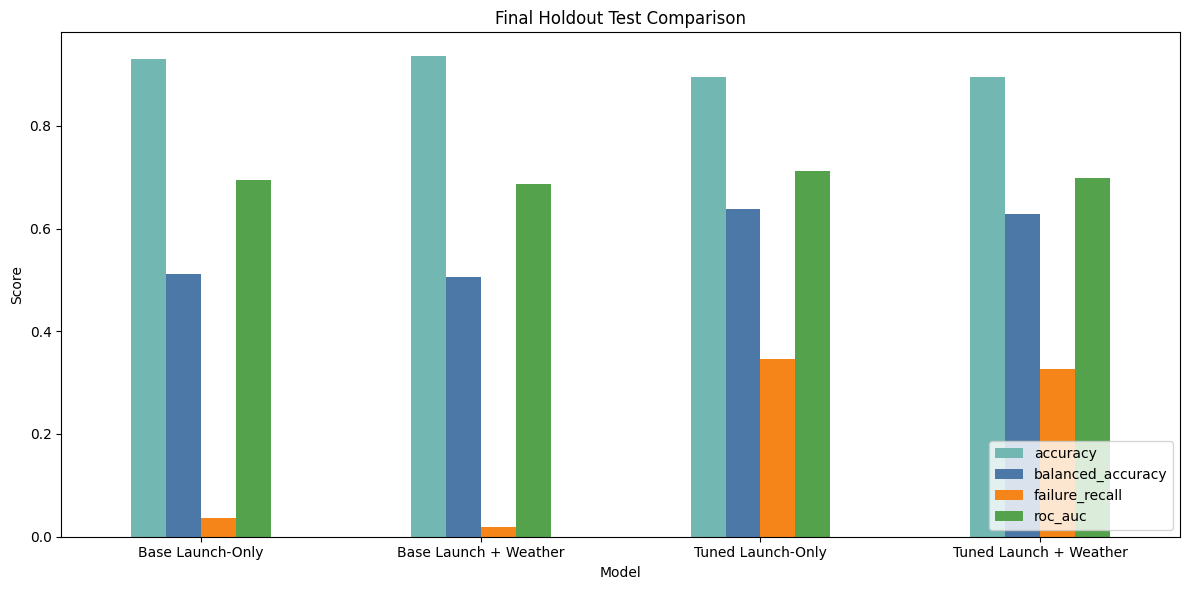

In [28]:
final_metric_plot_df = final_test_metrics.set_index("model")[
    ["accuracy", "balanced_accuracy", "failure_recall", "roc_auc"]
]

final_metric_plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#72b7b2", "#4c78a8", "#f58518", "#54a24b"],
)
plt.title("Final Holdout Test Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

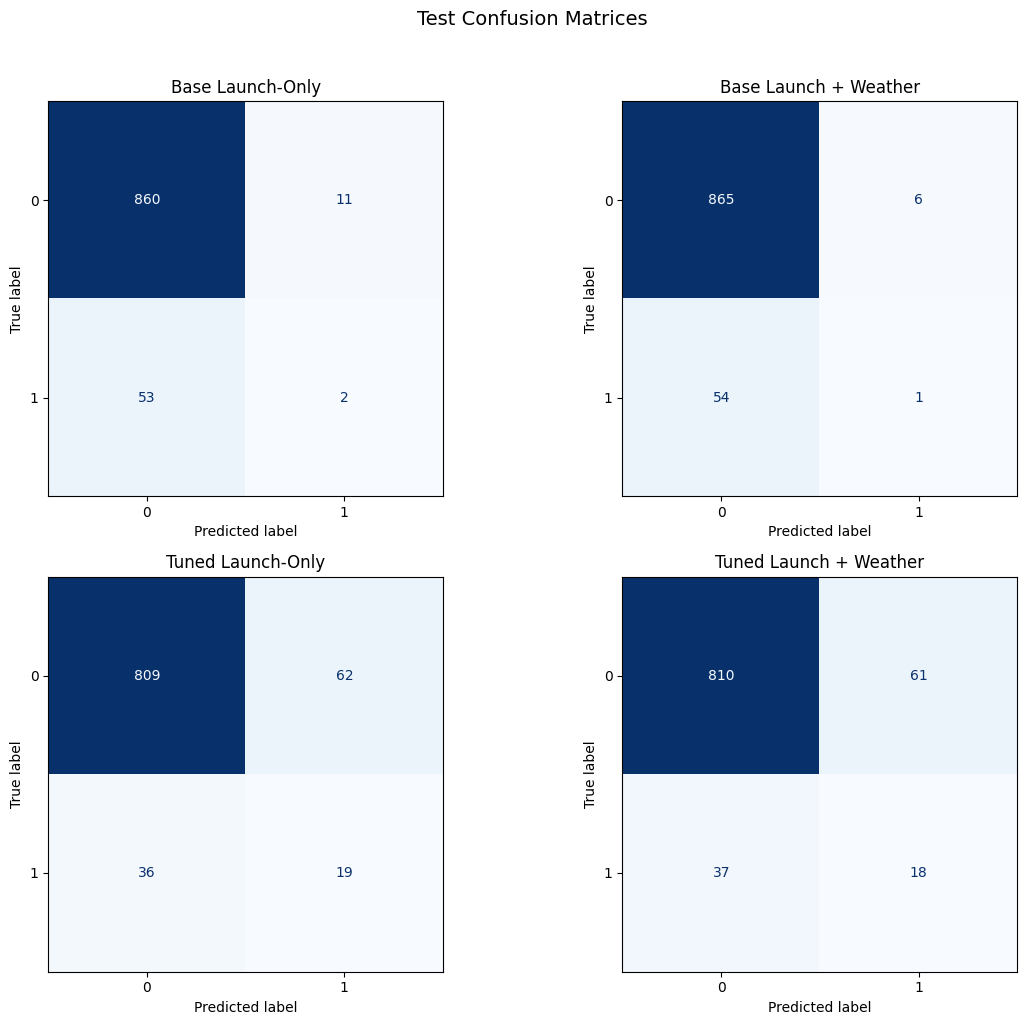

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

test_plot_inputs = [
    ("Base Launch-Only", final_models["Base Launch-Only"], split_data["launch_only"]["X_test"]),
    ("Base Launch + Weather", final_models["Base Launch + Weather"], split_data["launch_plus_weather"]["X_test"]),
    ("Tuned Launch-Only", final_models["Tuned Launch-Only"], split_data["launch_only"]["X_test"]),
    ("Tuned Launch + Weather", final_models["Tuned Launch + Weather"], split_data["launch_plus_weather"]["X_test"]),
]

for ax, (model_name, model, X_test_current) in zip(axes, test_plot_inputs):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(X_test_current),
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Test Confusion Matrices", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

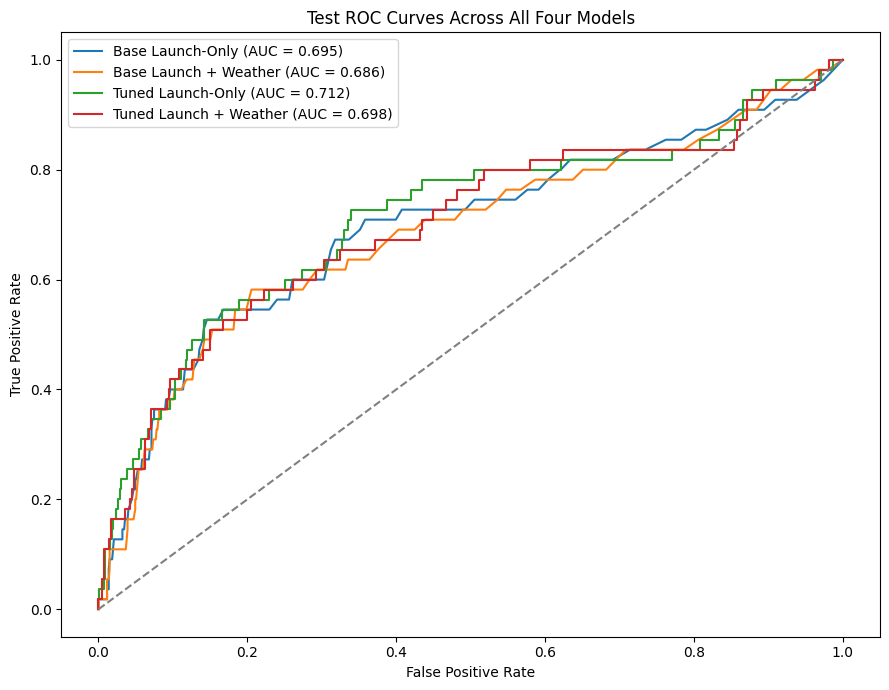

In [30]:
plt.figure(figsize=(9, 7))
for model_name, model, X_test_current in test_plot_inputs:
    y_score = model.predict_proba(X_test_current)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves Across All Four Models")
plt.legend()
plt.tight_layout()
plt.show()

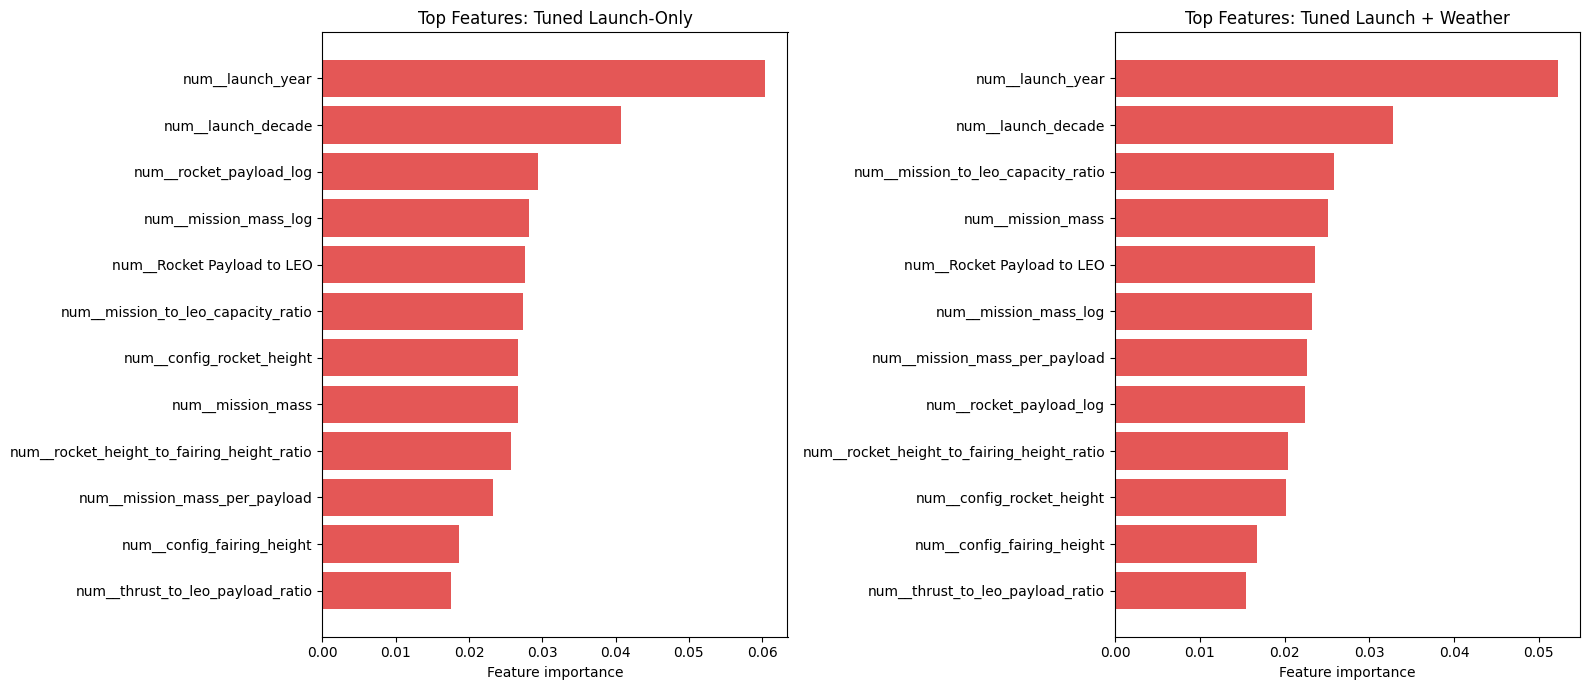

In [31]:
tuned_feature_importances = {
    "Tuned Launch-Only": get_feature_importance_frame(final_models["Tuned Launch-Only"], top_n=12),
    "Tuned Launch + Weather": get_feature_importance_frame(final_models["Tuned Launch + Weather"], top_n=12),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (model_name, importance_df) in zip(axes, tuned_feature_importances.items()):
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color="#e45756",
    )
    ax.set_title(f"Top Features: {model_name}")
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.show()

In [32]:
print(interpretation_text(final_test_metrics, focus_split="test"))

Best ROC AUC on test: Tuned Launch-Only (0.7118).
Best balanced accuracy on test: Tuned Launch-Only (0.6371).
Weather lift in the base models: -0.0086 ROC AUC.
Weather lift in the tuned models: -0.0139 ROC AUC.


## Summary

This notebook answers the same questions as the baseline modeling notebook, but under a
richer predictor set created from explicit feature engineering:

1. Do engineered launch features improve the launch-only model?
2. Do engineered weather features add useful lift beyond engineered launch features?
3. Does tuning still matter after feature engineering?
4. Which engineered model is strongest on the untouched holdout test split?

The most important model is not necessarily the one with the highest raw accuracy. For this
imbalanced launch-failure problem, balanced accuracy, failure recall, and ROC AUC remain
the more informative metrics for judging whether the new features are actually helping.